# Explore here

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from typing import Dict, List, Tuple
import joblib
# modelado
from sklearn.model_selection import train_test_split, GridSearchCV

# escalado y encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:


archivo = '/workspaces/antonio.romero.machine-learning-python-template/data/raw/internal-link.csv'
df = pd.read_csv(archivo)

In [3]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [4]:
df.shape

(48895, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
# porcentage de nulos
top_missing = (
    df.isna().mean().sort_values(ascending=False) * 100
).round(2).reset_index()
top_missing.columns = ["column", "missing_%"]
display(top_missing.head(20))

,column,missing_%
0,last_review,20.56
1,reviews_per_month,20.56
2,host_name,0.04
3,name,0.03
4,neighbourhood_group,0.00
5,neighbourhood,0.00
6,id,0.00
7,host_id,0.00
8,longitude,0.00
9,latitude,0.00


In [7]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()
df_duplicados = df[duplicados]
df_sin_duplicados = df.drop_duplicates()
df.duplicated().sum()
df.drop("id", axis = 1).duplicated().sum()

np.int64(0)

In [8]:
df.drop(["id", "host_id", "host_name"], axis = 1, inplace = True)


In [9]:
df.head()

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Skylit Midtown Castle,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   neighbourhood_group             48895 non-null  object 
 2   neighbourhood                   48895 non-null  object 
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  object 
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   last_review                     38843 non-null  object 
 10  reviews_per_month               38843 non-null  float64
 11  calculated_host_listings_count  48895 non-null  int64  
 12  availability_365                

In [11]:
df.name.value_counts()

name
Hillside Hotel                                        18
Home away from home                                   17
New york Multi-unit building                          16
Brooklyn Apartment                                    12
Private Room                                          11
                                                      ..
Spacious Modern Alcove Studio in a Luxury Building     1
Artist's Room in Large Apartment                       1
Modern Oasis in Central Park Slope                     1
One BR upper east, walk out to garden                  1
ASTORIA APARTMENT OUTDOOR SPACE                        1
Name: count, Length: 47905, dtype: int64

In [12]:
df.neighbourhood_group.value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [13]:
df.neighbourhood.value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [14]:
df.room_type.value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [15]:
df.minimum_nights.value_counts()

minimum_nights
1      12720
2      11696
3       7999
30      3760
4       3303
       ...  
275        1
182        1
114        1
85         1
36         1
Name: count, Length: 109, dtype: int64

In [16]:
# Precio por tipo de habitación
if "price" in df.columns and "room_type" in df.columns:
    price_by_room = (
        df.groupby("room_type")["price"]
        .agg(["count", "median", "mean", "std", "min", "max"])
        .sort_values("median", ascending=False)
    )
    display(price_by_room)

,count,median,mean,std,min,max
room_type,,,,,,
Entire home/apt,25409,160.0,211.794246,284.041611,0,10000
Private room,22326,70.0,89.780973,160.205262,0,10000
Shared room,1160,45.0,70.127586,101.725252,0,1800


In [17]:
# Precio por grupo de barrio
if "price" in df.columns and "neighbourhood_group" in df.columns:
    price_by_ng = (
        df.groupby("neighbourhood_group")["price"]
        .agg(["count", "median", "mean", "std", "min", "max"])
        .sort_values("median", ascending=False)
    )
    display(price_by_ng)

,count,median,mean,std,min,max
neighbourhood_group,,,,,,
Manhattan,21661,150.0,196.875814,291.383183,0,10000
Brooklyn,20104,90.0,124.383207,186.873538,0,10000
Queens,5666,75.0,99.517649,167.102155,10,10000
Staten Island,373,75.0,114.812332,277.620403,13,5000
Bronx,1091,65.0,87.496792,106.709349,0,2500


In [18]:
# Correlación de precios
numeric_cols = df.select_dtypes(include=["number"]).columns
corr = df[numeric_cols].corr(numeric_only=True)
if "price" in corr.columns:
    corr_price = corr["price"].sort_values(ascending=False).to_frame(name="corr_with_price")
    display(corr_price)

,corr_with_price
price,1.000000
availability_365,0.081829
calculated_host_listings_count,0.057472
minimum_nights,0.042799
latitude,0.033939
reviews_per_month,-0.030608
number_of_reviews,-0.047954
longitude,-0.150019


In [19]:
# Resumen de precios por percentiles
df["price"].describe(percentiles=[.25, .5, .75, .9, .95, .99])

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
90%        269.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64

In [20]:
# Definir los límites inferior y superior
# Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 334.0 y -90.0, con un rango intercuartílico de 106.0


In [21]:
def cap_outliers(s: pd.Series, upper_q: float = 0.95):
    """
    Winsorización simple para mejorar legibilidad en gráficos/tablas.
    """
    cap = s.quantile(upper_q)
    return s.clip(upper=cap), cap

if "price" in df.columns:
    df["_price_cap"], p95_cap = cap_outliers(df["price"], 0.95)
    print(f"Cap aplicado a 'price' en p95={p95_cap:.2f}")

Cap aplicado a 'price' en p95=355.00


### Visualizaciones

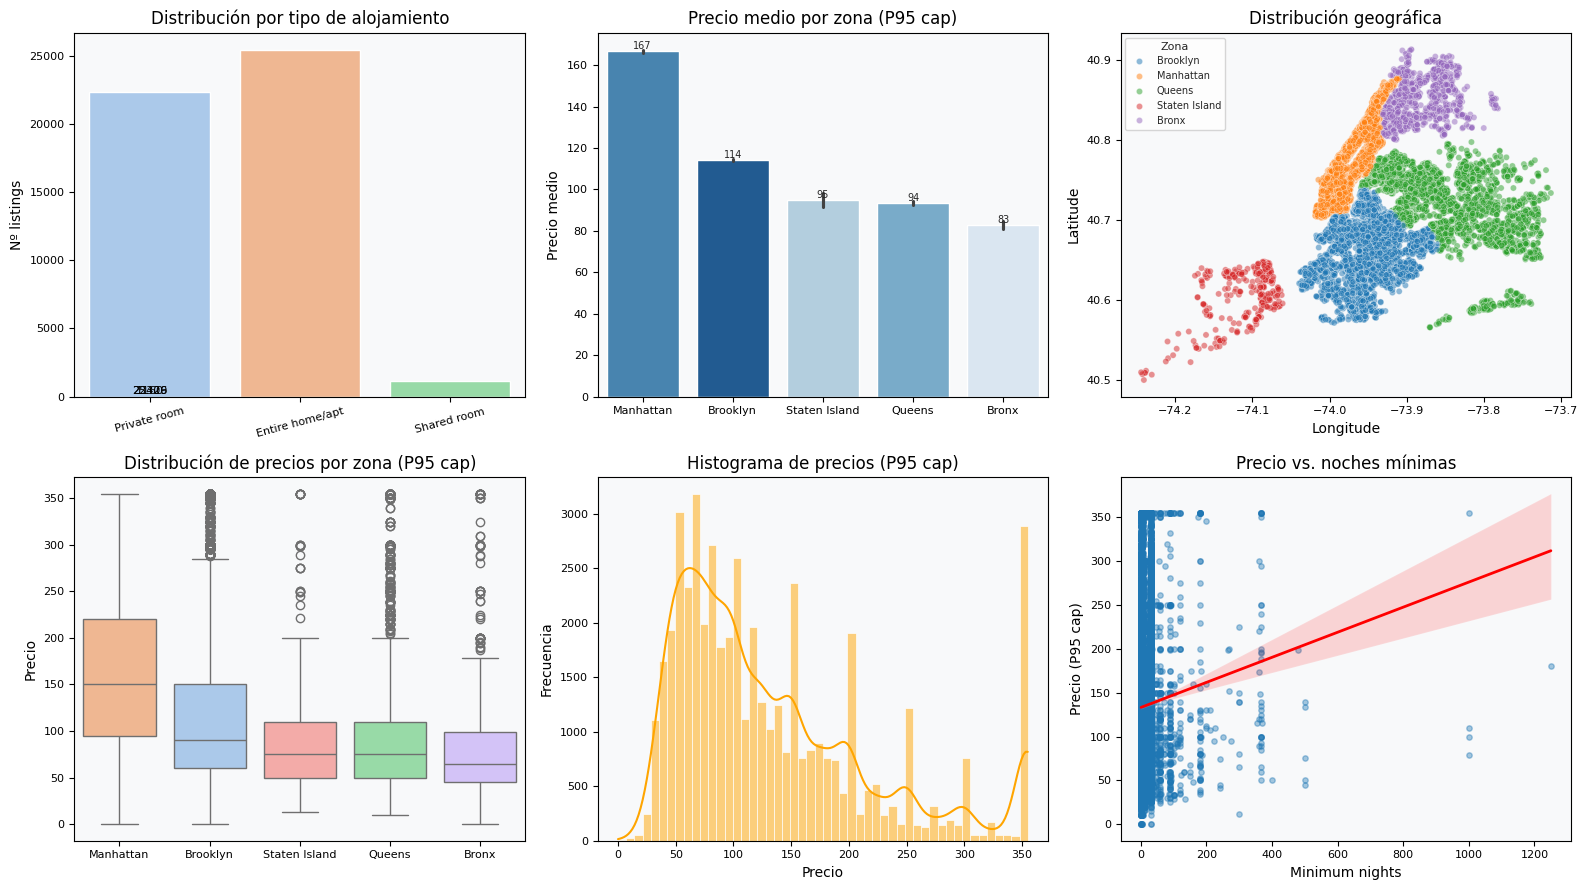

In [22]:

# Ajustes previos
df2 = df.copy()
p95 = df2["price"].quantile(0.95)
df2["price_clip"] = df2["price"].clip(upper=p95)

order_ng = (
    df2.groupby("neighbourhood_group")["price_clip"]
    .mean()
    .sort_values(ascending=False)
    .index
)

fig, axis = plt.subplots(2, 3, figsize=(16, 9))
sns.set_style("whitegrid")

# Countplot de tipos de habitación
sns.countplot(
    ax=axis[0, 0],
    data=df2,
    x="room_type",
    hue="room_type",         
    palette="pastel",
    legend=False
)
axis[0, 0].set(title="Distribución por tipo de alojamiento", xlabel=None, ylabel="Nº listings")
axis[0, 0].tick_params(axis='x', labelrotation=15)
for p in axis[0, 0].patches:
    axis[0, 0].annotate(f"{int(p.get_height())}",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3))

# Barplot: precio medio por zona
sns.barplot(
    ax=axis[0, 1],
    data=df2,
    x="neighbourhood_group",
    y="price_clip",
    hue="neighbourhood_group",  
    order=order_ng,
    estimator=np.mean,
    errorbar="se",
    legend=False,
    palette="Blues_r"
)
axis[0, 1].set(title="Precio medio por zona (P95 cap)", xlabel=None, ylabel="Precio medio")
for container in axis[0, 1].containers:
    axis[0, 1].bar_label(container, fmt="%.0f", fontsize=7, label_type="edge")

# Dispersión geográfica
sns.scatterplot(
    ax=axis[0, 2],
    data=df2,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    s=20,
    alpha=0.5
)
axis[0, 2].set(title="Distribución geográfica", xlabel="Longitude", ylabel="Latitude")
axis[0, 2].legend(title="Zona", fontsize=7, title_fontsize=8, loc="best")

# Boxplot: precios por zona
sns.boxplot(
    ax=axis[1, 0],
    data=df2,
    x="neighbourhood_group",
    y="price_clip",
    order=order_ng,
    hue="neighbourhood_group", 
    palette="pastel",
    legend=False
)
axis[1, 0].set(title="Distribución de precios por zona (P95 cap)", xlabel=None, ylabel="Precio")

# Histograma de precios
sns.histplot(
    ax=axis[1, 1],
    data=df2,
    x="price_clip",
    bins=50,
    kde=True,
    color="orange"
)
axis[1, 1].set(title="Histograma de precios (P95 cap)", xlabel="Precio", ylabel="Frecuencia")

# Relación precio vs. noches mínimas
sns.regplot(
    ax=axis[1, 2],
    data=df2,
    x="minimum_nights",
    y="price_clip",
    scatter_kws={"s": 15, "alpha": 0.4},
    line_kws={"linewidth": 2, "color": "red"}
)
axis[1, 2].set(title="Precio vs. noches mínimas", xlabel="Minimum nights", ylabel="Precio (P95 cap)")

# --- Estética del set
for ax in axis.ravel():
    ax.tick_params(axis='both', labelsize=8)
    ax.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()



Del análisis anterior podemos obtener las siguientes conclusiones:

Precio mediano = 106 (p25: 69 | p75: 175 | p99: 799). Distribución muy sesgada con long tail y outliers.

Medianas por tipo de alojamiento:

    Entire home/apt: 160
    Private room: 70
    Shared room: 45

Precio (medianas) e inventario por barrio:
    Manhattan: 150 y 44% de inventario
    Brooklyn: 90 y 41 % de inventario
    Queens: 75 y 12% de inventario
    Staten Island: 75 y 0,8% de inventario
    Brox 65 y 2% de inventario

Nulos de casi 21% en last_review y reviews_per_month.

La variación de precio parace basarse sobre todo en la ubicación y el tipo de habitación, y no tanto disponibilidad ni reseñas de forma directa.  

### Factorización 

In [23]:
# Detectar columnas categóricas: object, category y booleanos.
 
def detect_categoricals(df: pd.DataFrame, max_unique_for_numeric_as_cat: int = 20) -> List[str]:
    cats = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    return sorted(list(set(cats)))

# Aplicar la factorización a cada columna categórica.
def factorize_categoricals(df: pd.DataFrame, cat_cols: List[str]) -> Tuple[pd.DataFrame, Dict[str, Dict[str, dict]]]:
    df_out = df.copy()
    mappings: Dict[str, Dict[str, dict]] = {}
    for c in cat_cols:
        codes, uniques = pd.factorize(df_out[c], sort=True)  # códigos deterministas por orden
        df_out[f"{c}_code"] = codes
        to_code = {cat: int(i) for i, cat in enumerate(uniques)}
        to_cat  = {int(i): cat for i, cat in enumerate(uniques)}
        mappings[c] = {"to_code": to_code, "to_cat": to_cat}

    return df_out, mappings

cat_cols = detect_categoricals(df)
df_fact, mappings = factorize_categoricals(df, cat_cols)

print(f"Categóricas detectadas: {cat_cols}")


Categóricas detectadas: ['last_review', 'name', 'neighbourhood', 'neighbourhood_group', 'room_type']


In [24]:
# Hacemos el split
target = "price"
df_ = df.dropna(subset=[target]).copy()
X = df_.drop(columns=[target])
y = df_[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

In [25]:
# preprocessing
# --- 3️⃣ Pipelines de preprocesado ---
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True, dtype=np.float32))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    sparse_threshold=1.0
)
